# Week 9: Operational ML for KPC Revenue Assurance
**Detecting problem demurrage charges before they are billed**
Brian Mugambi | Power Learn Project, Week 9 | Capstone: KPC Revenue Assurance & Demurrage Platform

> **Data note.** The platform's seeded database holds only ~100 truck movements and 3 disputes, far too few to train a model. This notebook therefore **simulates 12,000 KPC-style gate movements**. All customers and carriers are anonymised IDs, and every number below comes from simulated data, so results show the *method*, not real KPC performance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             make_scorer, precision_score, recall_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from imblearn.pipeline import Pipeline as ImbPipeline      # applies SMOTE inside each CV training fold only
from imblearn.over_sampling import SMOTENC                   # SMOTE variant that handles 0/1 flag columns
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)
print("Libraries loaded.")

Libraries loaded.


## 1. Problem definition

**Operational problem:** Fraud / leakage detection on demurrage (tanker waiting-fee) charges.

**Why it matters:** A charge that is wrong, manipulated or unsupported either loses KPC revenue (under-billing) or triggers customer disputes (over-billing). Checking every charge by hand is slow.

**Target variable:** `flagged_for_review` = **1** if the charge turns out to be problematic (manipulated gate times, a waiver claimed with no breakdown on record, a movement not confirmed by GPS or gate pass, or a weighbridge ticket mismatch), **0** otherwise.

**Framing:** the model *prioritises charges for a human reviewer*. It never accuses a customer or driver of anything.

**The four problem types simulated** mirror the platform's compliance rules. They only partly show up in the data, so some problem charges look normal, as in real life:

| Problem type | Visible clue |
|---|---|
| Manipulated gate times | Hand-typed times, a large gap between weighbridge exit and gate-out, inflated dwell |
| False waiver | Waiver claimed, no breakdown on record |
| Unverified movement | No GPS confirmation and/or invalid electronic gate pass |
| Weighbridge mismatch | Large gap between tare and gross scale tickets |

In [2]:
# ------------------------------------------------------------------
# SIMULATED KPC-LIKE GATE LOG. The platform's real seeded database has only ~100 movements and
# 3 disputes, far too few to train a model, so we generate 12,000 movements over one year.
# Customers and carriers are anonymised IDs. No real company appears in this dataset.
# ------------------------------------------------------------------
DEPOTS = ["KOSF-PS01", "NBI-PS10", "NAK-PS25", "ELD-PS27", "KIS-PS28"]   # KPC terminal codes

def simulate_movements(n=12_000, seed=SEED):
    rng = np.random.default_rng(seed)

    # --- timeline (kept in time order: important for leakage-safe validation later) ---
    gate_in = pd.Timestamp("2025-01-01") + pd.to_timedelta(rng.uniform(0, 365 * 24 * 3600, n), unit="s")
    df = pd.DataFrame({"gate_in": gate_in}).sort_values("gate_in").reset_index(drop=True)
    df["movement_id"] = [f"MV-{i:05d}" for i in range(1, n + 1)]
    df["depot"] = rng.choice(DEPOTS, n, p=[0.30, 0.28, 0.14, 0.14, 0.14])
    df["customer_id"] = rng.choice([f"OMC-{i:02d}" for i in range(1, 13)], n)

    # --- carriers differ in how often they cause problem charges (a few are much riskier) ---
    n_car = 60
    carrier_risk = rng.gamma(2.0, 0.5, n_car)                # mean 1.0
    ci = rng.integers(0, n_car, n)
    df["carrier_id"] = np.array([f"CAR-{i:03d}" for i in range(1, n_car + 1)])[ci]
    risk = carrier_risk[ci]

    # --- normal behaviour of a road tanker at the gate ---
    free_hours = rng.choice([24, 24, 36, 48], n)              # contracted free time
    overstay = rng.random(n) < 0.12                           # 12% of trucks legitimately overstay
    dwell = np.where(overstay, free_hours + rng.uniform(1, 30, n), rng.lognormal(np.log(8), 0.45, n))
    gap = np.clip(rng.normal(25, 10, n), 1, None)             # minutes between weighbridge exit and gate-out
    scale_var = np.abs(rng.normal(0.6, 0.4, n))               # % difference between tare/gross scale tickets
    geofence = rng.random(n) > 0.04                           # GPS confirms the truck was at the depot
    egp = rng.random(n) > 0.03                                # electronic gate pass valid
    manual = rng.random(n) < np.clip(0.04 * risk, 0, 0.4)     # gate times typed in by hand (legitimate sometimes)
    waiver = rng.random(n) < 0.05                             # customer claims a terminal-side breakdown waiver
    breakdown = np.where(waiver, rng.random(n) < 0.85, rng.random(n) < 0.02)  # breakdown actually on record
    disputes = rng.poisson(0.3 * risk)                        # disputes raised by this customer/carrier, last 90 days

    # --- hidden ground truth: which charges are actually problematic (leakage / manipulation) ---
    is_problem = rng.random(n) < np.clip(0.022 * risk, 0, 0.25)
    ptype = rng.choice(["timestamp", "waiver", "unverified", "scale"], n, p=[0.40, 0.25, 0.20, 0.15])
    r = lambda p: rng.random(n) < p                           # patterns only partly show: some problems look normal

    m = is_problem & (ptype == "timestamp")                   # 1) manipulated gate times
    manual = np.where(m & r(0.85), True, manual)
    gap = np.where(m & r(0.70), rng.normal(150, 60, n), gap)
    dwell = np.where(m & r(0.80), dwell + rng.uniform(6, 24, n), dwell)

    m = is_problem & (ptype == "waiver")                      # 2) waiver claimed with no breakdown on record
    waiver = np.where(m & r(0.95), True, waiver)
    breakdown = np.where(m & r(0.90), False, breakdown)
    dwell = np.where(m & r(0.80), free_hours + rng.uniform(2, 20, n), dwell)

    m = is_problem & (ptype == "unverified")                  # 3) movement not confirmed by GPS / gate pass
    geofence = np.where(m & r(0.80), False, geofence)
    egp = np.where(m & r(0.60), False, egp)

    m = is_problem & (ptype == "scale")                       # 4) weighbridge ticket mismatch
    scale_var = np.where(m & r(0.90), np.abs(rng.normal(3.5, 1.5, n)), scale_var)

    df["free_hours"] = free_hours
    df["dwell_hours"] = dwell.round(2)
    df["overstay_hours"] = np.maximum(dwell - free_hours, 0).round(2)
    df["gate_out_weighbridge_gap_min"] = gap.round(1)
    df["scale_variance_pct"] = scale_var.round(2)
    df["gate_in_hour"] = df["gate_in"].dt.hour
    df["is_weekend"] = (df["gate_in"].dt.dayofweek >= 5).astype(int)
    df["manual_time_entry"] = manual.astype(int)
    df["geofence_confirmed"] = geofence.astype(int)
    df["egp_valid"] = egp.astype(int)
    df["waiver_claimed"] = waiver.astype(int)
    df["breakdown_logged"] = breakdown.astype(int)
    df["customer_disputes_90d"] = disputes
    # Domain feature: a waiver claimed with no breakdown on record is a red flag
    df["unsupported_waiver"] = ((df["waiver_claimed"] == 1) & (df["breakdown_logged"] == 0)).astype(int)
    df["flagged_for_review"] = is_problem.astype(int)          # TARGET
    return df

df = simulate_movements()
print(f"{len(df):,} movements from {df.gate_in.min():%d %b %Y} to {df.gate_in.max():%d %b %Y}")
df.head()

12,000 movements from 01 Jan 2025 to 31 Dec 2025


,gate_in,movement_id,depot,customer_id,carrier_id,free_hours,dwell_hours,overstay_hours,gate_out_weighbridge_gap_min,scale_variance_pct,gate_in_hour,is_weekend,manual_time_entry,geofence_confirmed,egp_valid,waiver_claimed,breakdown_logged,customer_disputes_90d,unsupported_waiver,flagged_for_review
0,2025-01-01 00:06:55.283588559,MV-00001,NBI-PS10,OMC-03,CAR-002,36,11.52,0.0,28.1,0.08,0,0,0,1,1,0,0,0,0,0
1,2025-01-01 02:45:15.537895926,MV-00002,NBI-PS10,OMC-10,CAR-012,24,7.50,0.0,22.1,0.42,2,0,0,1,1,0,0,0,0,0
2,2025-01-01 03:39:07.891456283,MV-00003,KOSF-PS01,OMC-04,CAR-045,24,8.86,0.0,30.3,0.06,3,0,0,1,1,0,0,1,0,0
3,2025-01-01 03:56:16.254277719,MV-00004,KIS-PS28,OMC-07,CAR-016,24,9.47,0.0,31.2,0.93,3,0,0,1,1,0,0,0,0,0
4,2025-01-01 04:32:39.116009689,MV-00005,KOSF-PS01,OMC-11,CAR-003,24,6.17,0.0,26.0,1.49,4,0,0,1,1,0,0,1,0,0


## 2. Data preparation and imbalance check
Only about 2% of charges are problems, so **accuracy is a trap**: a model that never flags anything scores about 98%. The rest of the notebook is built to avoid that trap.

Class counts:
 flagged_for_review
Normal charge     11785
Problem charge      215

Problem-charge rate: 1.79%


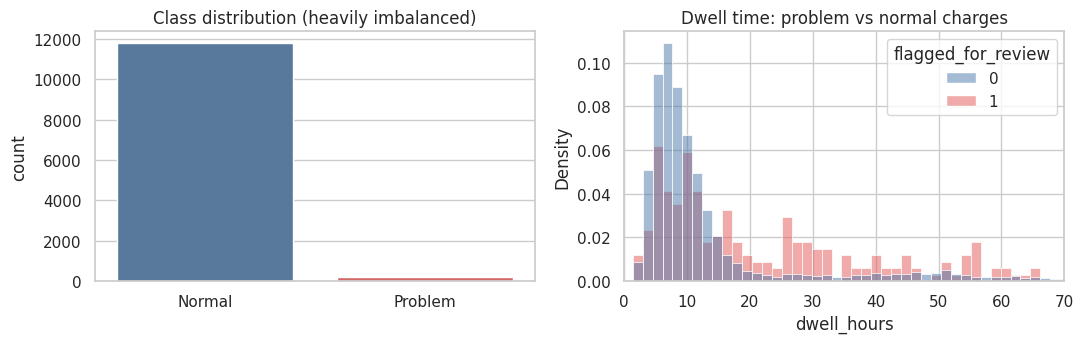

In [3]:
# ------------------------------------------------------------------
# 2. IMBALANCE CHECK
# ------------------------------------------------------------------
counts = df["flagged_for_review"].value_counts().sort_index()
print("Class counts:\n", counts.rename({0: "Normal charge", 1: "Problem charge"}).to_string())
print(f"\nProblem-charge rate: {df['flagged_for_review'].mean():.2%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.countplot(x="flagged_for_review", data=df, ax=ax[0], palette=["#4C78A8", "#E45756"])
ax[0].set_xticklabels(["Normal", "Problem"]); ax[0].set_title("Class distribution (heavily imbalanced)")
ax[0].set_xlabel("")
sns.histplot(data=df, x="dwell_hours", hue="flagged_for_review", bins=50, ax=ax[1],
             palette=["#4C78A8", "#E45756"], stat="density", common_norm=False)
ax[1].set_title("Dwell time: problem vs normal charges"); ax[1].set_xlim(0, 70)
plt.tight_layout(); plt.show()

### Leakage-safe split
Movements are ordered in time, so we **split by date, not at random**: train on the past (60%), tune the alert threshold on the next slice (15%), and test on the most recent period (25%). The test set is never used for any decision. We also keep the compliance score and all IDs out of the features, because the label is built from the same rules (that would be target leakage).

In [4]:
# ------------------------------------------------------------------
# DATA PREP: TIME-BASED SPLIT (prevents leakage)
# Movements happen over time, so a random shuffle would let the model "see the future" during
# training. We train on the past, tune the alert threshold on the next slice, and test on the latest.
# ------------------------------------------------------------------
FEATURES_RAW = ["dwell_hours", "free_hours", "overstay_hours", "gate_out_weighbridge_gap_min",
                "scale_variance_pct", "gate_in_hour", "is_weekend", "manual_time_entry",
                "geofence_confirmed", "egp_valid", "waiver_claimed", "breakdown_logged",
                "customer_disputes_90d", "unsupported_waiver"]
# NOTE: IDs, timestamps and the carrier ID are deliberately NOT features, and no compliance score is used,
# because the label would be built from the same rules (that would be target leakage).

X = pd.concat([df[FEATURES_RAW], pd.get_dummies(df["depot"], prefix="depot").astype(int)], axis=1)
y = df["flagged_for_review"]
BINARY_COLS = ["is_weekend", "manual_time_entry", "geofence_confirmed", "egp_valid", "waiver_claimed",
               "breakdown_logged", "unsupported_waiver"] + [c for c in X.columns if c.startswith("depot_")]
BINARY_IDX = [X.columns.get_loc(c) for c in BINARY_COLS]           # tells SMOTENC which columns are 0/1 flags

n = len(df); i_train, i_val = int(0.60 * n), int(0.75 * n)
X_train, y_train = X.iloc[:i_train], y.iloc[:i_train]
X_val,   y_val   = X.iloc[i_train:i_val], y.iloc[i_train:i_val]
X_test,  y_test  = X.iloc[i_val:], y.iloc[i_val:]

for name, part, idx in [("Train", y_train, slice(0, i_train)), ("Validation", y_val, slice(i_train, i_val)),
                        ("Test", y_test, slice(i_val, n))]:
    d = df.iloc[idx]
    print(f"{name:<11} {len(part):>6,} rows | {d.gate_in.min():%b %Y} to {d.gate_in.max():%b %Y} | "
          f"problem rate {part.mean():.2%} ({part.sum()} cases)")

# The ACCURACY TRAP: a model that never flags anything
naive_acc = accuracy_score(y_test, np.zeros(len(y_test), dtype=int))
print(f"\nA 'flag nothing' model scores {naive_acc:.2%} accuracy on the test set, yet catches 0 problem charges.")

Train        7,200 rows | Jan 2025 to Aug 2025 | problem rate 1.85% (133 cases)
Validation   1,800 rows | Aug 2025 to Sep 2025 | problem rate 1.67% (30 cases)
Test         3,000 rows | Sep 2025 to Dec 2025 | problem rate 1.73% (52 cases)

A 'flag nothing' model scores 98.27% accuracy on the test set, yet catches 0 problem charges.


## 3. Model training and cross-validation
We compare a do-nothing baseline against three real candidates, handling imbalance two ways (class weights, and SMOTE).

**Why these metrics (documentation for the operational context):**
- **Recall** = share of real problem charges we catch. A missed problem is lost revenue or a later dispute.
- **Precision** = share of alerts that are real. Every false alert costs reviewer time.
- **F1** balances the two. **ROC-AUC** checks how well the model ranks risky above safe charges.
- **PR-AUC** is our headline metric because it stays honest when positives are rare.
- **Accuracy is deliberately ignored.**

**Cross-validation** uses `TimeSeriesSplit` (five folds, each trained on the past and validated on the future). SMOTE sits inside an `imblearn` Pipeline, so it only ever touches the training part of each fold.

In [5]:
# ------------------------------------------------------------------
# 3. MODEL TRAINING + CROSS-VALIDATION
# Four candidates. Imbalance is handled two ways: class weights (RF, XGBoost) and SMOTE (XGBoost).
# CV uses TimeSeriesSplit (each fold trains on the past and validates on the future) rather than
# random K-fold, because random folds would leak future information in this time-ordered log.
# SMOTE lives inside an imblearn Pipeline, so it only ever touches the training part of each fold.
# ------------------------------------------------------------------
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos                                                     # scale_pos_weight = negatives / positives
print(f"scale_pos_weight for XGBoost = {spw:.1f}")

models = {
    "Baseline (never flags)": DummyClassifier(strategy="most_frequent"),
    "Random Forest + class weights": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
    "XGBoost + class weights": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="aucpr", random_state=SEED, n_jobs=-1),
    "XGBoost + SMOTE": ImbPipeline([
        ("smote", SMOTENC(categorical_features=BINARY_IDX, random_state=SEED)),
        ("xgb", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, eval_metric="aucpr", random_state=SEED, n_jobs=-1))]),
}

# Metric choice: accuracy is ignored. PR-AUC (average precision) is the headline metric because it stays
# honest when positives are rare; recall = share of problem charges caught; precision = share of alerts that
# were real (each false alert costs reviewer time); F1 balances the two; ROC-AUC checks ranking quality.
scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc",
           "recall": make_scorer(recall_score, zero_division=0),
           "precision": make_scorer(precision_score, zero_division=0),
           "f1": make_scorer(f1_score, zero_division=0)}

tscv = TimeSeriesSplit(n_splits=5)
rows = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=1)
    rows.append({"model": name, **{m: cv[f"test_{m}"].mean() for m in scoring},
                 "pr_auc_std": cv["test_pr_auc"].std()})
cv_table = pd.DataFrame(rows).set_index("model").round(3)
cv_table.sort_values("pr_auc", ascending=False)

scale_pos_weight for XGBoost = 53.1


,pr_auc,roc_auc,recall,precision,f1,pr_auc_std
model,,,,,,
Random Forest + class weights,0.643,0.947,0.356,0.871,0.455,0.116
XGBoost + class weights,0.593,0.924,0.552,0.584,0.538,0.156
XGBoost + SMOTE,0.463,0.865,0.455,0.588,0.473,0.137
Baseline (never flags),0.020,0.500,0.000,0.000,0.000,0.003


**Reading the cross-validation table.** The baseline's PR-AUC (about 0.02) is the "random guess" floor. **Random Forest with class weights leads on PR-AUC (0.64) and ROC-AUC (0.95)**, and is very precise (0.87) but catches fewer problems at the default threshold (recall 0.36). XGBoost with class weights catches more (recall 0.55) with lower precision. **SMOTE was the weakest option here (PR-AUC 0.46)**, probably because interpolating between 0/1 flag columns creates synthetic charges that don't resemble real ones. The fold-to-fold spread is large (about ±0.12 to 0.16), so the gap between Random Forest and XGBoost is *suggestive, not conclusive*.

In [6]:
# Fit every model on the training period and score it on the untouched TEST period (default 0.5 threshold)
fitted, test_rows = {}, []
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    test_rows.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                      "precision": precision_score(y_test, pred, zero_division=0),
                      "recall": recall_score(y_test, pred, zero_division=0),
                      "f1": f1_score(y_test, pred, zero_division=0),
                      "roc_auc": roc_auc_score(y_test, proba),
                      "pr_auc": average_precision_score(y_test, proba)})
test_table = pd.DataFrame(test_rows).set_index("model").round(3)
test_table

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Baseline (never flags),0.983,0.000,0.000,0.000,0.500,0.017
Random Forest + class weights,0.991,0.861,0.596,0.705,0.964,0.662
XGBoost + class weights,0.983,0.508,0.615,0.557,0.955,0.619
XGBoost + SMOTE,0.979,0.424,0.538,0.475,0.843,0.516


**Reading the test results (default 0.5 cut-off).** The baseline reaches 98.3% accuracy while catching nothing, which is exactly why accuracy is not used to judge these models. Random Forest again leads on PR-AUC (0.66) and ROC-AUC (0.96). It is selected because it won cross-validation, and the test set confirmed it without being used to choose it.

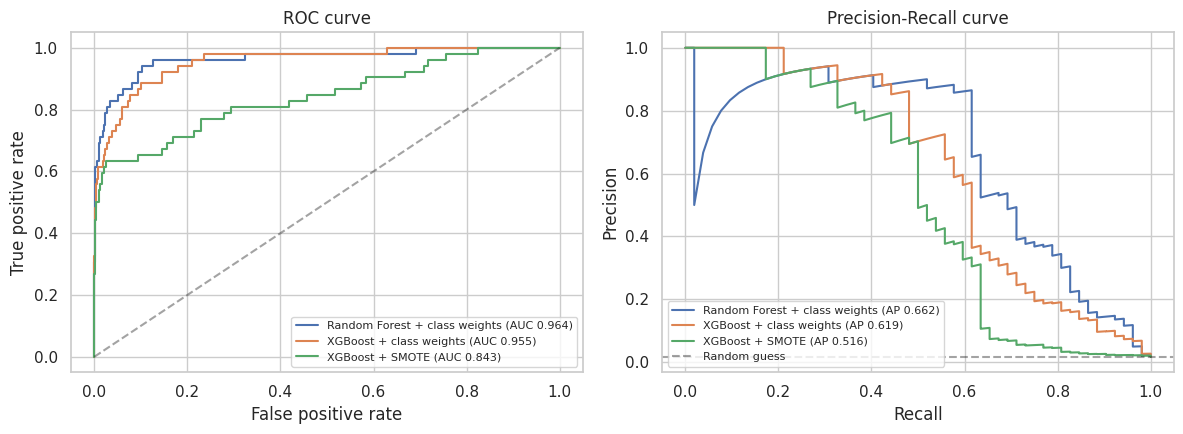

In [7]:
# ------------------------------------------------------------------
# 4. EVALUATION VISUALS: ROC and Precision-Recall curves on the TEST period
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, model in fitted.items():
    if name.startswith("Baseline"):
        continue
    p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p); pr, rc, _ = precision_recall_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
    ax[1].plot(rc, pr, label=f"{name} (AP {average_precision_score(y_test, p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=.4); ax[0].set_title("ROC curve"); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[1].axhline(y_test.mean(), color="k", ls="--", alpha=.4, label="Random guess"); ax[1].set_title("Precision-Recall curve")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Evaluation and choosing the alert threshold
A fixed 0.5 cut-off is arbitrary. In operations the two errors have very different costs, so we choose the threshold that **minimises expected business cost**, tuned on the *validation* slice only.

**Cost assumptions (placeholders to replace with Finance figures):** a missed problem charge costs about **KES 30,000**; reviewing one flagged charge costs about **KES 600**. A missed problem is therefore about 50 times as costly as a false alarm, so the best threshold is low.

Selected model: Random Forest + class weights
Cost-optimal threshold on validation data: 0.13


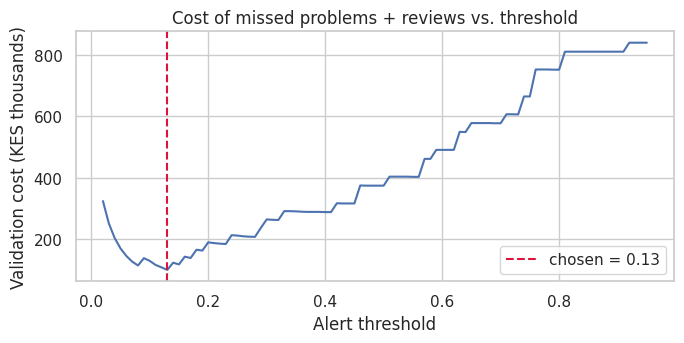

In [8]:
# ------------------------------------------------------------------
# CHOOSING THE ALERT THRESHOLD FROM BUSINESS COST (tuned on the VALIDATION slice, never on the test set)
# ASSUMPTIONS (replace with Finance figures): a problem charge we miss loses ~KES 30,000 of revenue,
# and reviewing one flagged charge costs ~KES 600 of staff time.
# ------------------------------------------------------------------
COST_MISSED, COST_REVIEW = 30_000, 600
BEST_NAME = cv_table["pr_auc"].idxmax()            # model chosen by cross-validated PR-AUC
best_model = fitted[BEST_NAME]
print("Selected model:", BEST_NAME)

def total_cost(y_true, proba, thr):
    flagged = proba >= thr
    missed = ((~flagged) & (y_true == 1)).sum()
    return missed * COST_MISSED + flagged.sum() * COST_REVIEW

p_val = best_model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.02, 0.95, 94)
val_cost = [total_cost(y_val.values, p_val, t) for t in thresholds]
THRESHOLD = float(thresholds[int(np.argmin(val_cost))])
print(f"Cost-optimal threshold on validation data: {THRESHOLD:.2f}")

plt.figure(figsize=(7, 3.6))
plt.plot(thresholds, np.array(val_cost) / 1e3)
plt.axvline(THRESHOLD, color="crimson", ls="--", label=f"chosen = {THRESHOLD:.2f}")
plt.xlabel("Alert threshold"); plt.ylabel("Validation cost (KES thousands)")
plt.title("Cost of missed problems + reviews vs. threshold"); plt.legend(); plt.tight_layout(); plt.show()

=== Random Forest + class weights | threshold 0.13 | TEST period ===
              precision    recall  f1-score   support

      Normal      0.997     0.957     0.976      2948
     Problem      0.253     0.827     0.387        52

    accuracy                          0.955      3000
   macro avg      0.625     0.892     0.682      3000
weighted avg      0.984     0.955     0.966      3000

ROC-AUC: 0.964 | PR-AUC: 0.662


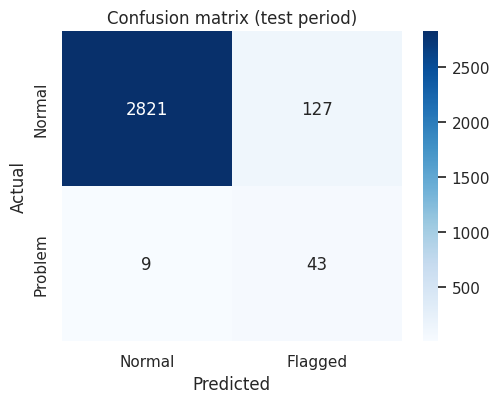

Caught 43 of 52 problem charges; 127 false alarms; 9 missed.
Cost with model:          KES      372,000
Cost with no model:       KES    1,560,000
Cost of reviewing all:    KES    1,800,000
Saving vs no model:       KES    1,188,000 over the 3,000-movement test period (assumed costs)

At the default 0.5 cut-off: caught 31 of 52, 5 false alarms, cost KES 651,600



95% bootstrap ranges -> Recall: 0.72 to 0.93 | Precision: 0.19 to 0.33 | PR-AUC: 0.53 to 0.80


In [9]:
# ------------------------------------------------------------------
# FINAL EVALUATION on the TEST period at the chosen threshold
# ------------------------------------------------------------------
p_test = best_model.predict_proba(X_test)[:, 1]
y_hat = (p_test >= THRESHOLD).astype(int)

print(f"=== {BEST_NAME} | threshold {THRESHOLD:.2f} | TEST period ===")
print(classification_report(y_test, y_hat, target_names=["Normal", "Problem"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, p_test):.3f} | PR-AUC: {average_precision_score(y_test, p_test):.3f}")

cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Flagged"], yticklabels=["Normal", "Problem"])
plt.title("Confusion matrix (test period)"); plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
cost_model = fn * COST_MISSED + (tp + fp) * COST_REVIEW
cost_nothing = y_test.sum() * COST_MISSED                       # no model: every problem charge is missed
cost_everything = len(y_test) * COST_REVIEW                      # review every single charge by hand
print(f"Caught {tp} of {tp + fn} problem charges; {fp} false alarms; {fn} missed.")
print(f"Cost with model:          KES {cost_model:>12,.0f}")
print(f"Cost with no model:       KES {cost_nothing:>12,.0f}")
print(f"Cost of reviewing all:    KES {cost_everything:>12,.0f}")
print(f"Saving vs no model:       KES {cost_nothing - cost_model:>12,.0f} over the {len(y_test):,}-movement test period (assumed costs)")

# For comparison: what a fixed, default 0.5 cut-off would have done on the same test period
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, (p_test >= 0.5).astype(int)).ravel()
print(f"\nAt the default 0.5 cut-off: caught {tp5} of {tp5 + fn5}, {fp5} false alarms, cost KES {fn5 * COST_MISSED + (tp5 + fp5) * COST_REVIEW:,.0f}")

# The test period has few problem cases, so a single number can mislead. Bootstrap = re-score 1,000 random
# re-draws of the test set to see how much the results could plausibly move.
rng = np.random.default_rng(SEED)
yt, pt = y_test.values, p_test
recalls, precisions, aps = [], [], []
for _ in range(1000):
    b = rng.integers(0, len(yt), len(yt))
    if yt[b].sum() == 0:
        continue
    pred_b = (pt[b] >= THRESHOLD).astype(int)
    recalls.append(recall_score(yt[b], pred_b, zero_division=0))
    precisions.append(precision_score(yt[b], pred_b, zero_division=0))
    aps.append(average_precision_score(yt[b], pt[b]))
ci = lambda v: f"{np.percentile(v, 2.5):.2f} to {np.percentile(v, 97.5):.2f}"
print(f"\n95% bootstrap ranges -> Recall: {ci(recalls)} | Precision: {ci(precisions)} | PR-AUC: {ci(aps)}")

**Reading the final result.** At the cost-optimal threshold (0.13) the model caught **43 of 52 problem charges (recall 0.83)** in the test period, at the price of **127 false alarms (precision only 0.25)**, so roughly one alert in four is a real problem. That trade is deliberate. The default 0.5 cut-off would have caught only 31 of 52 with just 5 false alarms; lowering the threshold costs about 122 extra reviews (roughly KES 73,000) to catch 12 more problem charges (roughly KES 360,000 at stake).

Under the assumed costs, the total came to about KES 372,000, versus KES 652,000 at the default 0.5 cut-off, KES 1,560,000 for doing nothing and KES 1,800,000 for reviewing everything.

**Be cautious with these numbers.** The test period contains only 52 problem cases. Bootstrap re-sampling gives 95% ranges of roughly **0.72 to 0.93 for recall, 0.19 to 0.33 for precision and 0.53 to 0.80 for PR-AUC**, so treat single values as approximate. The results also come from simulated data with an assumed pattern, which real data may not follow as cleanly.

## 5. Bonus: K-Means segmentation of carriers
Without using the problem labels, we group the 60 carriers by behaviour (dwell time, manual entries, GPS misses, unsupported waivers, scale variance, disputes). The features are standardised first because K-Means relies on distances. The problem rate is added *afterwards* to interpret the segments.

Silhouette by k: {2: 0.213, 3: 0.173, 4: 0.178, 5: 0.189, 6: 0.17} -> chosen k = 2


,carriers,movements,avg_dwell_hours,manual_entry_rate,geofence_miss_rate,unsupported_waiver_rate,avg_scale_variance,avg_disputes_90d,problem_rate
segment,,,,,,,,,
0,33,6623,13.288,0.026,0.040,0.009,0.626,0.152,0.009
1,27,5377,13.990,0.065,0.047,0.016,0.625,0.442,0.029


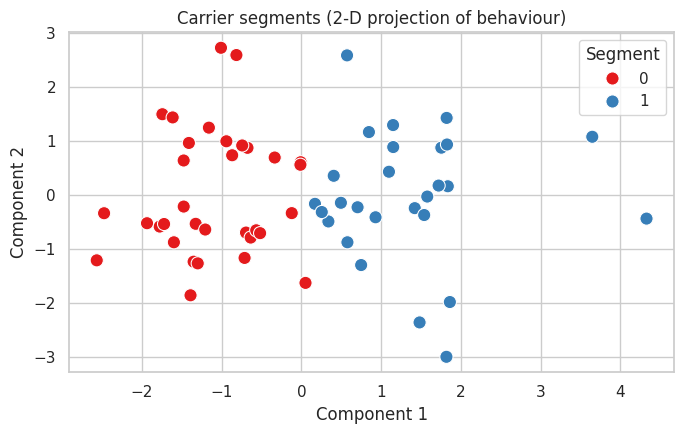

In [10]:
# ------------------------------------------------------------------
# 5. BONUS: K-MEANS SEGMENTATION OF CARRIERS (unsupervised, no labels used to form the clusters)
# Goal: group the 60 carriers by behaviour so the audit team can focus on the riskiest segment.
# Features are standardised first because K-Means is distance-based.
# ------------------------------------------------------------------
car = df.groupby("carrier_id").agg(
    movements=("movement_id", "count"), avg_dwell_hours=("dwell_hours", "mean"),
    manual_entry_rate=("manual_time_entry", "mean"), geofence_miss_rate=("geofence_confirmed", lambda s: 1 - s.mean()),
    unsupported_waiver_rate=("unsupported_waiver", "mean"), avg_scale_variance=("scale_variance_pct", "mean"),
    avg_disputes_90d=("customer_disputes_90d", "mean"), problem_rate=("flagged_for_review", "mean"))

cluster_features = ["avg_dwell_hours", "manual_entry_rate", "geofence_miss_rate",
                    "unsupported_waiver_rate", "avg_scale_variance", "avg_disputes_90d"]   # problem_rate NOT used
Z = StandardScaler().fit_transform(car[cluster_features])

sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Z)) for k in range(2, 7)}
K = max(sil, key=sil.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in sil.items()}, "-> chosen k =", K)

car["segment"] = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(Z)
profile = car.groupby("segment").agg(carriers=("movements", "size"), movements=("movements", "sum"),
                                     **{c: (c, "mean") for c in cluster_features + ["problem_rate"]}).round(3)
display(profile)

xy = PCA(n_components=2, random_state=SEED).fit_transform(Z)
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=car["segment"], palette="Set1", s=90)
plt.title("Carrier segments (2-D projection of behaviour)"); plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.legend(title="Segment"); plt.tight_layout(); plt.show()

**Reading the segments.** Silhouette scores are low (best is 0.21 at k = 2), so the separation is weak and the segments should be seen as a rough guide. Even so, Segment 1 (27 carriers) has about 2.5 times the manual-entry rate (6.5% vs 2.6%), about 3 times the disputes (0.44 vs 0.15) and about 3 times the problem-charge rate (2.9% vs 0.9%) of Segment 0. That gives the audit team a simple starting point: review this group first.

## 6. Explainability: why does the model flag a charge?
We use the model's built-in importance and **SHAP** to open the black box. SHAP gives each field a signed contribution to a specific alert (the *local* view) and to the model overall (the *global* view).

Explaining: Random Forest + class weights


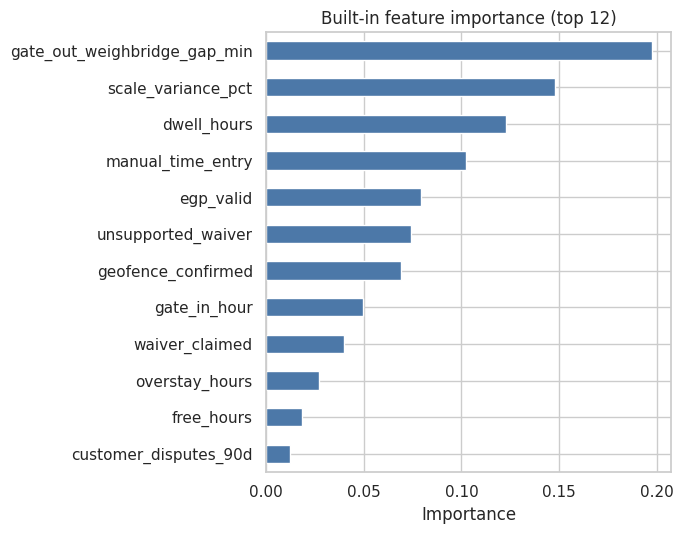

In [11]:
# ------------------------------------------------------------------
# 6. EXPLAINABILITY: built-in importance + SHAP
# We explain the model that WON cross-validation (tree-based, so SHAP values are exact and fast).
# ------------------------------------------------------------------
explain_model = best_model.steps[-1][1] if hasattr(best_model, "steps") else best_model
print("Explaining:", BEST_NAME)

imp = pd.Series(explain_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7, 5.5))
imp.tail(12).plot(kind="barh", color="#4C78A8")
plt.title("Built-in feature importance (top 12)"); plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("feature_importance_builtin.png", dpi=160); plt.show()

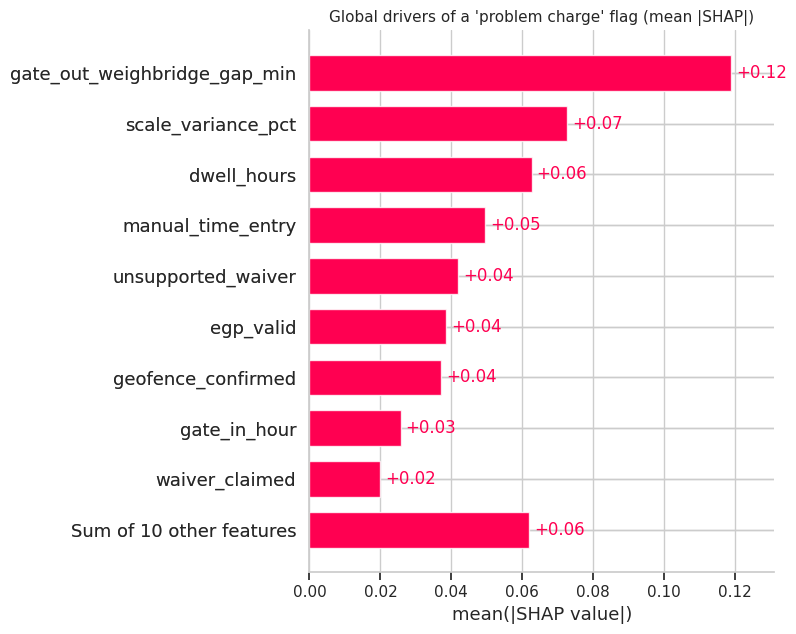

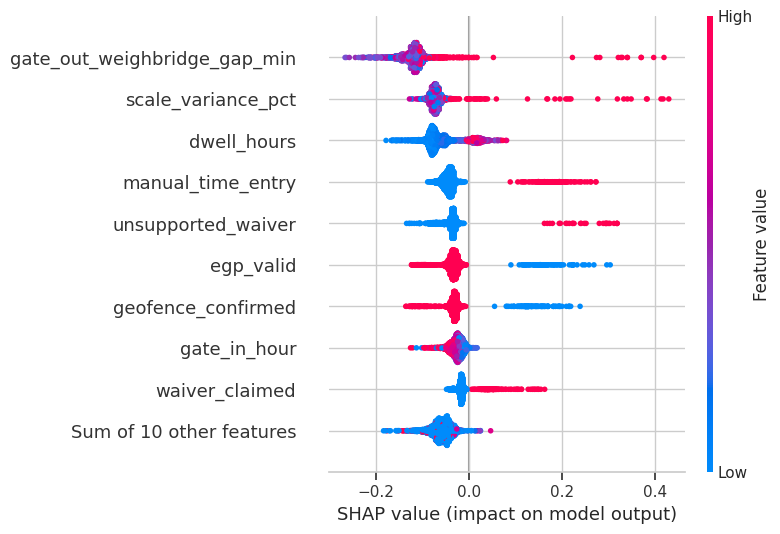

In [12]:
explainer = shap.TreeExplainer(explain_model)
sv = explainer(X_test, check_additivity=False)                   # SHAP values for every test movement
if sv.values.ndim == 3:                                           # sklearn forests return one set per class
    sv = sv[:, :, 1]                                              # keep class 1 = "problem charge"

# Global view: which fields drive alerts overall
plt.figure()
shap.plots.bar(sv, max_display=10, show=False)
plt.title("Global drivers of a 'problem charge' flag (mean |SHAP|)", fontsize=11)
plt.tight_layout(); plt.savefig("shap_bar.png", dpi=160, bbox_inches="tight"); plt.show()
pd.Series(np.abs(sv.values).mean(axis=0), index=X.columns).sort_values(ascending=False).to_csv("shap_importance.csv", header=["mean_abs_shap"])

# Direction of effect: red = high value of the field, blue = low value
plt.figure()
shap.plots.beeswarm(sv, max_display=10, show=False)
plt.tight_layout(); plt.savefig("shap_beeswarm.png", dpi=160, bbox_inches="tight"); plt.show()

Test movement #2963: risk score 0.95 (alert threshold 0.13)
dwell_hours                      19.46
overstay_hours                    0.00
gate_out_weighbridge_gap_min    305.10
manual_time_entry                 1.00
unsupported_waiver                0.00
geofence_confirmed                1.00
scale_variance_pct                0.62


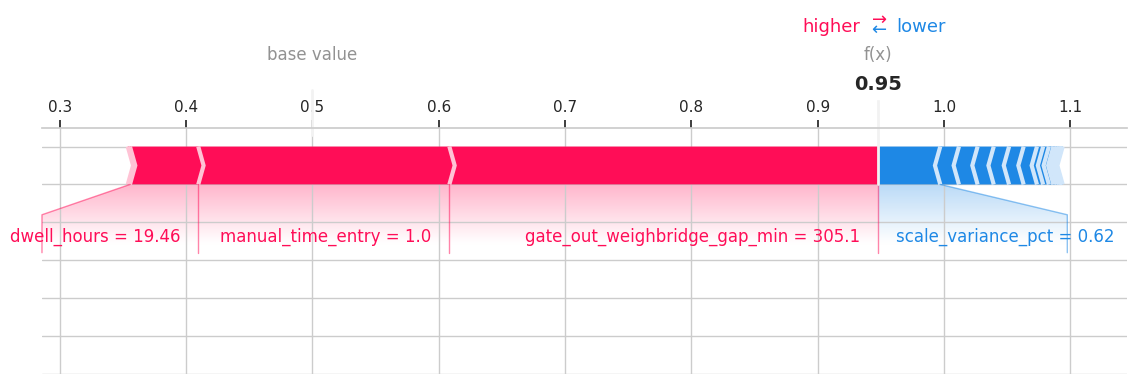

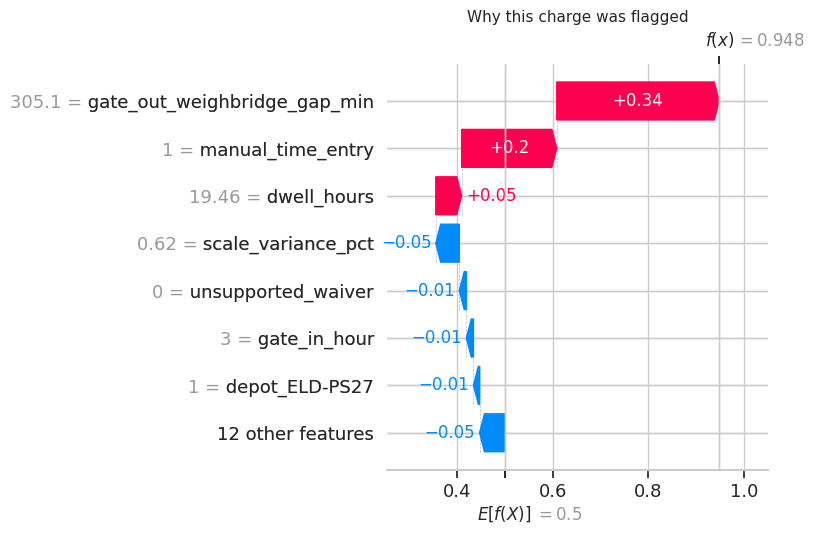

Note: class weighting rebalances the forest's votes, so this 'risk score' ranks charges rather than giving a literal probability. The alert threshold was therefore tuned on business cost, not fixed at 0.5.


In [13]:
# Local view: why was ONE specific charge flagged? Pick the highest-scoring correctly caught problem charge.
p_best = best_model.predict_proba(X_test)[:, 1]
caught = np.where((y_test.values == 1) & (p_best >= THRESHOLD))[0]
idx = caught[np.argmax(p_best[caught])]
print(f"Test movement #{idx}: risk score {p_best[idx]:.2f} (alert threshold {THRESHOLD:.2f})")
print(X_test.iloc[idx][["dwell_hours", "overstay_hours", "gate_out_weighbridge_gap_min", "manual_time_entry",
                        "unsupported_waiver", "geofence_confirmed", "scale_variance_pct"]].to_string())

# Force plot: red fields push the risk score up, blue fields push it down
shap.force_plot(sv.base_values[idx], sv.values[idx], X_test.iloc[idx].round(2), matplotlib=True, show=False)
plt.gcf().set_size_inches(14, 3.2)
plt.savefig("shap_force.png", dpi=160, bbox_inches="tight"); plt.show()

# Waterfall plot: the same explanation as a step-by-step list, easier for non-technical readers
plt.figure()
shap.plots.waterfall(sv[idx], max_display=8, show=False)
plt.title("Why this charge was flagged", fontsize=11)
plt.tight_layout(); plt.savefig("shap_waterfall.png", dpi=160, bbox_inches="tight"); plt.show()
print("Note: class weighting rebalances the forest's votes, so this 'risk score' ranks charges rather than giving a literal "
      "probability. The alert threshold was therefore tuned on business cost, not fixed at 0.5.")

**Reading the SHAP results.**
- **Top three drivers:** (1) the **gap between weighbridge exit and gate-out** (a very long or negative gap pushes risk up sharply), (2) the **scale-ticket variance**, and (3) **dwell time**. Hand-typed times (`manual_time_entry`), waivers with no breakdown on record, invalid gate passes and missing GPS confirmation come next.
- **Direction of effect (beeswarm):** high gap, high scale variance, long dwell, manual entry, unsupported waiver, invalid gate pass and missing GPS all push the risk score up, which matches operational common sense.
- **Something worth questioning:** `gate_in_hour` ranks 8th, yet in this simulation the hour of day has *no* true effect on problems. With only 133 problem cases in training, the trees latched onto noise. A real project should drop or test that feature.
- **Score scale:** because class weights rebalance the forest's votes, the score ranks charges rather than giving a literal probability (the baseline is 0.5, not 2%).

## Summary and limitations
- **Workflow:** time-based split, forward-chaining cross-validation, SMOTE inside the pipeline, cost-based threshold, and no leakage from IDs, dates or the compliance score.
- **Result:** Random Forest with class weights was the best of three models, catching about 83% of problem charges in the test period at a cost of many false alarms, which is the right trade when a miss costs about 50 times a review.
- **Limits:** simulated data; small test sample (wide bootstrap ranges); assumed costs; weak carrier segments; and a model that should support, never replace, a human reviewer.
- **Next steps:** retrain on real gate logs as the platform collects them, replace the assumed costs with Finance figures, and log reviewer outcomes so the model can learn from them.